In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('fintech_data_23_52_21240.csv')

print(df.columns)

#renaming columns to be all lower case with no special characters
def rename_columns(df):
    #make all cols lower case
    df.columns = df.columns.str.lower()
    #iterate through the column names and replace space with underscore,
    #using list comprehension
    df.columns = [col.replace(' ', '_') for col in df.columns]

rename_columns(df)
print(df.columns)

df.head()

Index(['Customer Id', 'Emp Title', 'Emp Length', 'Home Ownership',
       'Annual Inc', 'Annual Inc Joint', 'Verification Status', 'Zip Code',
       'Addr State', 'Avg Cur Bal', 'Tot Cur Bal', 'Loan Id', 'Loan Status',
       'Loan Amount', 'State', 'Funded Amount', 'Term', 'Int Rate', 'Grade',
       'Issue Date', 'Pymnt Plan', 'Type', 'Purpose', 'Description'],
      dtype='object')
Index(['customer_id', 'emp_title', 'emp_length', 'home_ownership',
       'annual_inc', 'annual_inc_joint', 'verification_status', 'zip_code',
       'addr_state', 'avg_cur_bal', 'tot_cur_bal', 'loan_id', 'loan_status',
       'loan_amount', 'state', 'funded_amount', 'term', 'int_rate', 'grade',
       'issue_date', 'pymnt_plan', 'type', 'purpose', 'description'],
      dtype='object')


,customer_id,emp_title,emp_length,home_ownership,annual_inc,annual_inc_joint,verification_status,zip_code,addr_state,avg_cur_bal,...,state,funded_amount,term,int_rate,grade,issue_date,pymnt_plan,type,purpose,description
0,YidnXHhlMzRceGRiXHgxYUxceDhjXlx4YzYiXHhjY1NceD...,Radiation Therapist,4 years,MORTGAGE,66000.0,NaN,Source Verified,551xx,MN,14224.0,...,MN,16000.0,60 months,0.1699,16,14 October 2014,False,INDIVIDUAL,debt_consolidation,Debt consolidation
1,YidFUlx4ZjM1XHhjYlx4YzJceDg4XHg5YTZceDFlXHgwNl...,Pastor,10+ years,RENT,65000.0,NaN,Verified,486xx,MI,13361.0,...,MI,13000.0,60 months,0.1845,19,18 May 2018,False,Individual,other,Other
2,YiddXHhkN1BceDBiU1x4ZTlceGRibVx4OTVkMlx4ZjlceG...,Attorney,3 years,RENT,108000.0,NaN,Source Verified,911xx,CA,7366.0,...,CA,20000.0,36 months,0.0735,4,17 December 2017,False,Individual,small_business,Business
3,YidaaVx4YzFceGFjXHhkY1x4ZTFceDk4XHgwNUNceGJjXH...,Mm Mm Pizza Inc,5 years,RENT,24000.0,NaN,Not Verified,152xx,PA,4732.0,...,PA,2400.0,36 months,0.1522,11,13 August 2013,False,INDIVIDUAL,moving,Relocation 2013
4,YidceGU4XHhmZFx4MWNbXHhmY1x4YjNceGMyXHg5OFZceD...,NaN,NaN,MORTGAGE,65544.0,NaN,Verified,198xx,DE,19839.0,...,DE,20000.0,36 months,0.1180,10,18 December 2018,False,Individual,debt_consolidation,Debt consolidation


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27030 entries, 0 to 27029
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          27030 non-null  object 
 1   emp_title            24621 non-null  object 
 2   emp_length           25119 non-null  object 
 3   home_ownership       27030 non-null  object 
 4   annual_inc           27030 non-null  float64
 5   annual_inc_joint     1835 non-null   float64
 6   verification_status  27030 non-null  object 
 7   zip_code             27030 non-null  object 
 8   addr_state           27030 non-null  object 
 9   avg_cur_bal          27030 non-null  float64
 10  tot_cur_bal          27030 non-null  float64
 11  loan_id              27030 non-null  int64  
 12  loan_status          27030 non-null  object 
 13  loan_amount          27030 non-null  float64
 14  state                27030 non-null  object 
 15  funded_amount        27030 non-null 

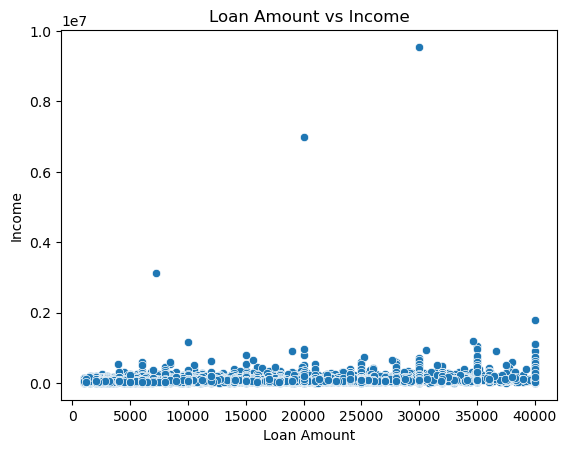

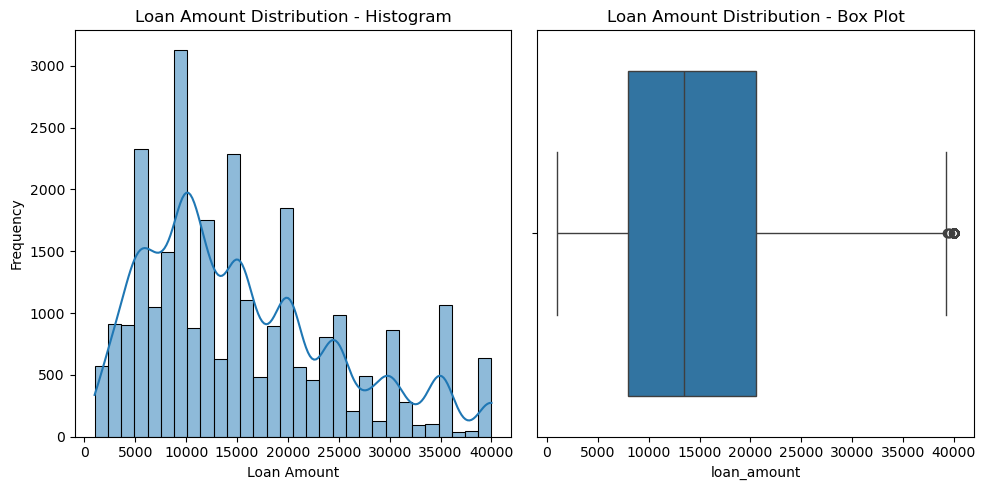

15459.586570477248 13500.0 40000.0


In [2]:
print(df.info())
#there are some missing data especially for the column 'annual_inc_joint' since not all people have joint loans
# other columns (emp_title, emp_length, int_rate, description) have only a small percentage of missing data

#does annual income affect loan amounts? to see that we will plot
# Create a scatter plot using Seaborn
sns.scatterplot(x='loan_amount', y='annual_inc', data=df)

# Add labels and a title to the plot
plt.xlabel('Loan Amount')
plt.ylabel('Income')
plt.title('Loan Amount vs Income')

# Display the plot
plt.show()

#from the plot, we conclude that income does not affect loan amounts, there are some outliers but generally, people request loans of different
# amounts irrelevant of their income

#how does the distribution of loan amounts look like?
plt.figure(figsize=(10, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['loan_amount'], bins=30, kde=True)
plt.title('Loan Amount Distribution - Histogram')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['loan_amount'])
plt.title('Loan Amount Distribution - Box Plot')

plt.tight_layout()
plt.show()

print(df.loan_amount.mean(), df.loan_amount.median(), df.loan_amount.max())
#from the histogram plot, we conclude that loan amounts column can be said to be right skewed, however mean and median are not very far from each other
# from the box plot, we see that there are some outliers

In [3]:
df.describe()
#std for annual income is large, therefore this dataset includes people of different income, this gives a better overview of data
# interest rates are almost constant no matter the loan amount (std very low)

,annual_inc,annual_inc_joint,avg_cur_bal,tot_cur_bal,loan_id,loan_amount,funded_amount,int_rate,grade
count,2.703000e+04,1.835000e+03,27030.000000,2.703000e+04,27030.000000,27030.00000,27030.00000,25816.000000,27030.000000
mean,7.974077e+04,1.301851e+05,13726.811876,1.450660e+05,135572.821273,15459.58657,15459.58657,0.130361,10.891232
std,9.251095e+04,7.559437e+04,16695.769343,1.654619e+05,77854.957913,9453.06528,9453.06528,0.048409,6.288577
min,1.000000e+03,2.300000e+04,0.000000,0.000000e+00,7.000000,1000.00000,1000.00000,0.053100,1.000000
25%,4.800000e+04,8.700000e+04,3081.000000,2.912025e+04,68333.000000,8000.00000,8000.00000,0.094300,6.000000
50%,6.683650e+04,1.160000e+05,7328.000000,8.043650e+04,136064.000000,13500.00000,13500.00000,0.125900,10.000000
75%,9.500000e+04,1.520000e+05,19077.750000,2.176992e+05,203152.250000,20500.00000,20500.00000,0.159900,15.000000
max,9.550000e+06,1.250000e+06,293107.000000,4.127799e+06,270298.000000,40000.00000,40000.00000,0.309900,35.000000


In [4]:
print(df.customer_id.nunique(), df.loan_id.nunique())
#we have 2 unique id's for each entry, customer and loan, we will use loan id as an index since it is a numerical value
# and also much simpler than customer id, it's also relevant since we care more about loans
df2 = df.copy()
df2 = df2.set_index("loan_id")

df2

27030 27030


,customer_id,emp_title,emp_length,home_ownership,annual_inc,annual_inc_joint,verification_status,zip_code,addr_state,avg_cur_bal,...,state,funded_amount,term,int_rate,grade,issue_date,pymnt_plan,type,purpose,description
loan_id,,,,,,,,,,,,,,,,,,,,,
168686,YidnXHhlMzRceGRiXHgxYUxceDhjXlx4YzYiXHhjY1NceD...,Radiation Therapist,4 years,MORTGAGE,66000.0,NaN,Source Verified,551xx,MN,14224.0,...,MN,16000.0,60 months,0.1699,16,14 October 2014,False,INDIVIDUAL,debt_consolidation,Debt consolidation
134771,YidFUlx4ZjM1XHhjYlx4YzJceDg4XHg5YTZceDFlXHgwNl...,Pastor,10+ years,RENT,65000.0,NaN,Verified,486xx,MI,13361.0,...,MI,13000.0,60 months,0.1845,19,18 May 2018,False,Individual,other,Other
189329,YiddXHhkN1BceDBiU1x4ZTlceGRibVx4OTVkMlx4ZjlceG...,Attorney,3 years,RENT,108000.0,NaN,Source Verified,911xx,CA,7366.0,...,CA,20000.0,36 months,0.0735,4,17 December 2017,False,Individual,small_business,Business
6602,YidaaVx4YzFceGFjXHhkY1x4ZTFceDk4XHgwNUNceGJjXH...,Mm Mm Pizza Inc,5 years,RENT,24000.0,NaN,Not Verified,152xx,PA,4732.0,...,PA,2400.0,36 months,0.1522,11,13 August 2013,False,INDIVIDUAL,moving,Relocation 2013
192847,YidceGU4XHhmZFx4MWNbXHhmY1x4YjNceGMyXHg5OFZceD...,NaN,NaN,MORTGAGE,65544.0,NaN,Verified,198xx,DE,19839.0,...,DE,20000.0,36 months,0.1180,10,18 December 2018,False,Individual,debt_consolidation,Debt consolidation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144648,YidceGE3flx4YjVceDAyXT1eXHg5Nlx4OWUgYlx4YzhKRi...,Personal banker 3,3 years,RENT,50000.0,NaN,Source Verified,331xx,FL,3414.0,...,FL,15000.0,36 months,0.0943,6,18 May 2018,False,Individual,credit_card,Credit card refinancing
61475,YidceDk1XHhhOFx4MDc0eTJceGI5XHg4ZXBceGVjczFceG...,Team Lead,6 years,RENT,28425.0,NaN,Source Verified,930xx,CA,1658.0,...,CA,8000.0,36 months,0.0789,4,15 September 2015,False,Individual,debt_consolidation,Debt consolidation
191593,YidceGRkXHg4MkliXHgwOF5ceGE5XHgxZVx4OTJceGY1XH...,IT Specialist,4 years,RENT,122500.0,NaN,Verified,531xx,WI,2080.0,...,WI,20000.0,36 months,0.1041,8,18 March 2018,False,Individual,medical,Medical expenses


In [5]:
duplicates = df2[df2.duplicated()]
print(duplicates)
#we have no duplicated row
#however from the .head() applied above, we can observe the inconsistency in 'type' column (INDIVIDUAL & Individual), we need to handle that
print(df.type.unique(), df.type.value_counts())

def standardize_column_values(df, column, replacement):
    df[column] = df[column].str.lower().replace(replacement, regex=True)
    return df

replacement = {
    r'.*individual.*': 'Individual',  # Matches any variation of 'individual'
    r'.*joint.*': 'Joint',            # Matches any variation of 'joint'
    r'direct_pay': 'Direct Pay'       # Direct match for 'DIRECT_PAY'
}

df2 = standardize_column_values(df2, 'type', replacement)

print(df2.type.unique(), df2.type.value_counts())

Empty DataFrame
Columns: [customer_id, emp_title, emp_length, home_ownership, annual_inc, annual_inc_joint, verification_status, zip_code, addr_state, avg_cur_bal, tot_cur_bal, loan_status, loan_amount, state, funded_amount, term, int_rate, grade, issue_date, pymnt_plan, type, purpose, description]
Index: []

[0 rows x 23 columns]
['INDIVIDUAL' 'Individual' 'Joint App' 'JOINT' 'DIRECT_PAY'] type
Individual    16930
INDIVIDUAL     8235
Joint App      1748
JOINT            87
DIRECT_PAY       30
Name: count, dtype: int64
['Individual' 'Joint' 'Direct Pay'] type
Individual    25165
Joint          1835
Direct Pay       30
Name: count, dtype: int64


In [6]:
# Calculating sum of null entries and percentage of null entries
sum_null = df2.isnull().sum()
perc_null = df2.isnull().sum() / len(df2)
perc_null_mean = df2.isnull().mean()*100
sum_null,perc_null,perc_null_mean

#we have a large percentage of missing data in 'annual_inc_joint' because it is not applicable for all people, therefore it is MNAR,
# because it only exists for joint applicants, so there is a direct relationship between them
# for other columns, we need to inspect if there's a relation between missing values and columns

(customer_id                0
 emp_title               2409
 emp_length              1911
 home_ownership             0
 annual_inc                 0
 annual_inc_joint       25195
 verification_status        0
 zip_code                   0
 addr_state                 0
 avg_cur_bal                0
 tot_cur_bal                0
 loan_status                0
 loan_amount                0
 state                      0
 funded_amount              0
 term                       0
 int_rate                1214
 grade                      0
 issue_date                 0
 pymnt_plan                 0
 type                       0
 purpose                    0
 description              230
 dtype: int64,
 customer_id            0.000000
 emp_title              0.089123
 emp_length             0.070699
 home_ownership         0.000000
 annual_inc             0.000000
 annual_inc_joint       0.932112
 verification_status    0.000000
 zip_code               0.000000
 addr_state             0.00000

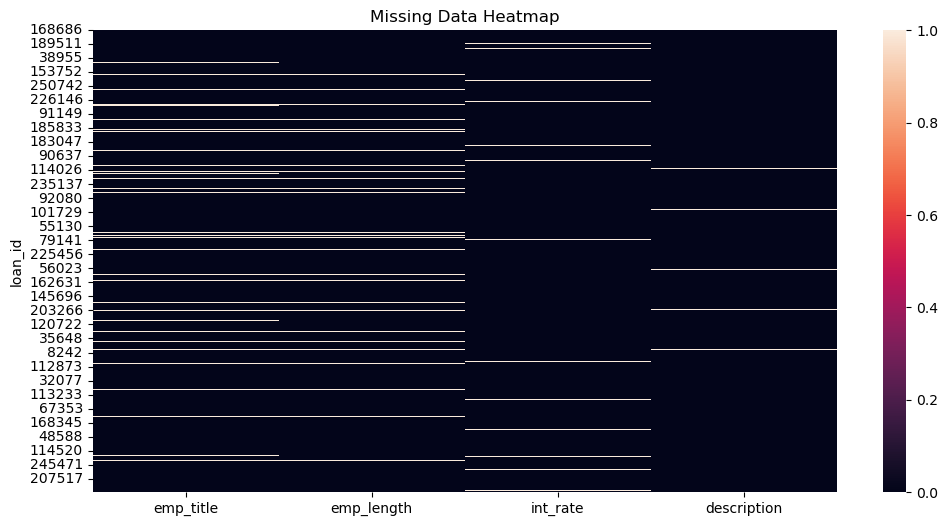

In [7]:
# Visualize missing data for specific columns
plt.figure(figsize=(12, 6))
sns.heatmap(df2[['emp_title', 'emp_length', 'int_rate', 'description']].isnull())
plt.title('Missing Data Heatmap')
plt.show()

#from the plot, we can observe a pattern between missing data in 'emp_title' and 'emp_length', where we do not know the employment length of
# people who did not provide their emplyment title, which makes sense.
# However, there are some missing 'emp_title' values in which we know the employment length which can mean that some data were lost
#for 'int_rate' and 'description' there is neither a pattern nor correlation with other missing data, so it can be said to be MCAR

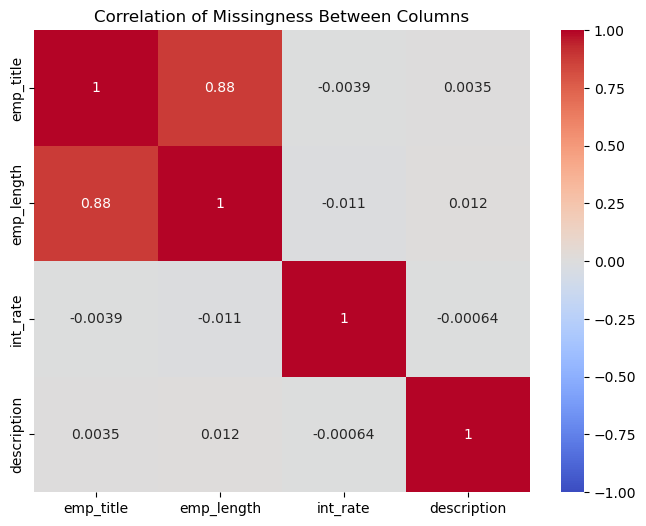

In [8]:
#to make sure we will use correlation matrix and visualize it

# Create missing data indicator columns (1 for missing, 0 for non-missing)
missing_data = df2[['emp_title', 'emp_length', 'int_rate', 'description']].isnull().astype(int)

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(missing_data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Missingness Between Columns')
plt.show()

#it is obvious that missing values in 'emp_title' and 'emp_length' are highly correlated, therefore these data are MAR (missing at random)
# since these missing values are related to the observed data, where most (even all) people who do not provide their employment length
# have not provided their job title as well

In [9]:
df3 = df2.copy()
df3 = df3.drop(columns=['customer_id'])
df3 #just to view more columns
print(df2.verification_status.unique(), df2.home_ownership.unique())
#assume 'source verified' is  different from 'verified', we will not handle it as an inconsistency in order not to manipulate data
#for 'home_ownership', we can easily make all values lower case
df2['home_ownership'] = df2['home_ownership'].str.capitalize()

['Source Verified' 'Verified' 'Not Verified'] ['MORTGAGE' 'RENT' 'OWN' 'ANY']


C:\Users\vip\AppData\Local\Temp\ipykernel_14340\1579173558.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df2['int_rate'])


loan_id
168686    0.1699
134771    0.1845
189329    0.0735
6602      0.1522
192847    0.1180
           ...  
144648    0.0943
61475     0.0789
191593    0.1041
226108    0.0789
193889    0.1333
Name: int_rate, Length: 27030, dtype: float64

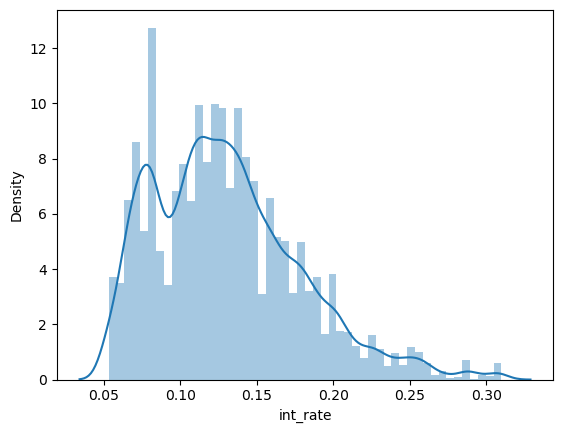

In [10]:
#now we want to impute missing data, for interest rate we can impute with the median in order not to be biased
# we do not want the imputation to affect the overall distribution of data, therefore we will not use the mean
# as shownn in the plot, the 'int_rate' column is positively skewed; not normally distributed
sns.distplot(df2['int_rate'])
df2['int_rate'] = df2['int_rate'].fillna(value=df2['int_rate'].median())
df2['int_rate']

In [11]:
#for 'description' column, the missing values are MCAR and the percentage of missing data is only 0.85%
# therefore, we will drop these missing values since they will not affect our analysis of the data
df2 = df2.dropna(subset=['description'])
print(df2.isnull().sum(), df2.customer_id.nunique())

customer_id                0
emp_title               2386
emp_length              1887
home_ownership             0
annual_inc                 0
annual_inc_joint       24972
verification_status        0
zip_code                   0
addr_state                 0
avg_cur_bal                0
tot_cur_bal                0
loan_status                0
loan_amount                0
state                      0
funded_amount              0
term                       0
int_rate                   0
grade                      0
issue_date                 0
pymnt_plan                 0
type                       0
purpose                    0
description                0
dtype: int64 26800


In [40]:
print(df2['emp_title'].unique(), df2['emp_title'].value_counts(), df2['emp_title'].isnull().sum())
#for 'emp_title', we will try to impute missing values with data related to the annual income, where for each missing value
# we will check the nearest annual income to this one, then impute the job title with the same one as the nearest neighbor
# it is something similar to KNN but since this is a categorical value we will not use KNN

def impute_emp_title(row, df):
    if pd.isnull(row['emp_title']):
        # Filter to find the nearest Annual Income with a known Emp Title
        nearest_rows = df[df['emp_title'].notnull()]
        
        if nearest_rows.empty:  # Check if there are no matching rows
            return 'Unknown'  # Use a placeholder like 'Not Provided'
        
        # Find the nearest match based on Annual Inc
        # Compute the absolute differences in Annual Inc
        differences = (nearest_rows['annual_inc'] - row['annual_inc']).abs()
        
        # Get the index of the nearest row
        nearest_index = differences.idxmin()
        
        # Return the Emp Title from the nearest row
        return df.loc[nearest_index, 'emp_title']
    else:
        return row['emp_title']  # Return the original title if not missing

# Apply the function to impute missing 'emp_title'
df2.loc[:, 'emp_title'] = df2.apply(lambda row: impute_emp_title(row, df2), axis=1)

print(df['emp_title'].unique(), df['emp_title'].value_counts(), df['emp_title'].isnull().sum())

#looking at unique() output  before and after, we can observe the difference where missing values were imputed with multiple values
# according to the nearest annual income, this is rather than imputing with only the mode, which is not very efficient

['Radiation Therapist' 'Pastor' 'Attorney' ... 'Bridge Worker'
 'Finance Director ' 'Personal banker 3'] emp_title
Teacher                          487
Manager                          425
Owner                            234
Driver                           229
Registered Nurse                 209
                                ... 
Sales and Logistics                1
Lead Data Warehouse Architect      1
Portfolio manager                  1
Client Analyst                     1
Personal banker 3                  1
Name: count, Length: 13049, dtype: int64 0
['Radiation Therapist' 'Pastor' 'Attorney' ... 'Bridge Worker'
 'Finance Director ' 'Personal banker 3'] emp_title
Teacher                      469
Manager                      403
Owner                        222
Driver                       203
Supervisor                   187
                            ... 
WC Adjuster                    1
Gym Teacher                    1
Structural Truss Designer      1
Bodytech               

In [56]:
#lastly, missing data for 'emp_length' will be imputed with the mode of the corresponding job title
# ex: if entry 15 is missing and its job title is teacher, then we will impute the 'emp_length' with the mode value of all teacher entries
print(df.emp_length.unique(), df.emp_length.value_counts(), df.emp_length.isnull().sum())

def impute_emp_length(row, mode_emp_length):
    if pd.isnull(row['emp_length']):
        emp_title = row['emp_title']
        if emp_title in mode_emp_length and pd.notnull(mode_emp_length[emp_title]):
            return mode_emp_length[emp_title]  # Return the mode for this title
        else:
            return np.nan  # Explicitly return np.nan if no mode is available
    else:
        return row['emp_length']  # Return the original value if not missing

def calculate_mode(group):
    if len(group) == 1:
        return group.iloc[0]  # If only one value, return it directly
    else:
        return group.mode()[0] if not group.mode().empty else np.nan

# Calculate the mode or single value of 'emp_length' for each 'emp_title'
mode_emp_length = df.groupby('emp_title')['emp_length'].agg(calculate_mode)

# Use .loc[] to ensure proper assignment
df2.loc[:, 'emp_length'] = df2.apply(lambda row: impute_emp_length(row, mode_emp_length), axis=1)

print(df2['emp_length'].unique(), df2['emp_length'].value_counts(), df2['emp_length'].isnull().sum())
#some categories have  no modes, therefore we will impute them with the global mode (only 2 missing values left)
df2.loc[:, 'emp_length'] = df2['emp_length'].fillna(df2['emp_length'].mode()[0])
#now we have no missing values at all
#lastly, for the annual_inc_joint column, we will drop the whole column but not now since we will need its values later

['4 years' '10+ years' '3 years' '5 years' nan '< 1 year' '9 years'
 '2 years' '1 year' '6 years' '7 years' '8 years'] emp_length
10+ years    8891
< 1 year     2524
2 years      2364
3 years      2085
1 year       1797
4 years      1643
5 years      1628
6 years      1186
8 years      1080
7 years      1070
9 years       851
Name: count, dtype: int64 1911
['4 years' '10+ years' '3 years' '5 years' '< 1 year' '9 years' '2 years'
 '1 year' '7 years' '6 years' '8 years'] emp_length
10+ years    9804
< 1 year     2710
2 years      2522
3 years      2102
1 year       1914
4 years      1789
5 years      1665
6 years      1255
8 years      1107
7 years      1080
9 years       852
Name: count, dtype: int64 0


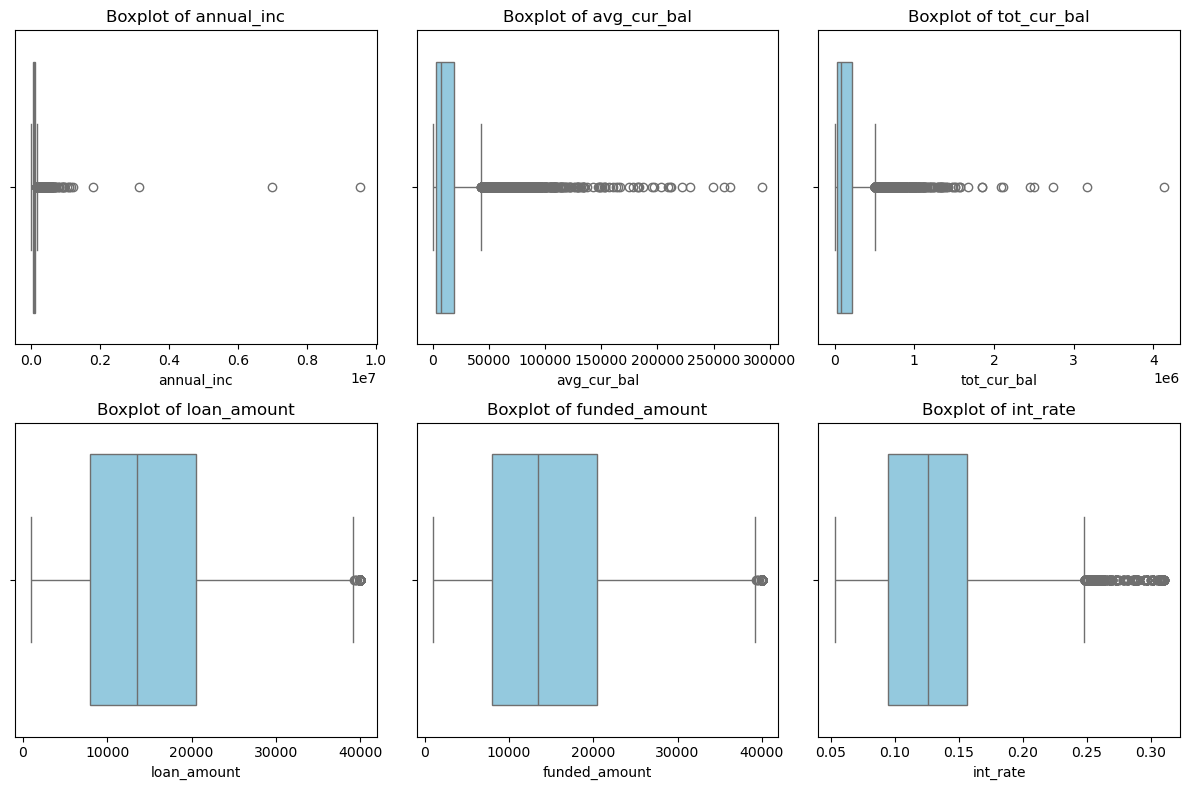

In [60]:
#now, for outliers: we have 6 numerical columns which are 'annual_inc', 'avg_cur_bal', 'tot_cur_bal', 'loan_amount',
# 'funded_amount' and 'int_rate'. Note: there are other numerical columns but these are the only ones which make sense in our context

columns = ['annual_inc', 'avg_cur_bal', 'tot_cur_bal', 'loan_amount', 'funded_amount', 'int_rate']

# Set the figure size
plt.figure(figsize=(12, 8))

# Loop through each column and create a boxplot
for i, column in enumerate(columns, 1):
    plt.subplot(2, 3, i)  # Create subplots, 2 rows, 3 columns
    sns.boxplot(x=df2[column], color='skyblue')
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)

# Adjust the layout so plots don’t overlap
plt.tight_layout()
plt.show()

#from the plots, we observe a large number of outliers in the first 3 columns, with few very high values in case of 'annual_inc'
# in the second 3 columns, the number of outliers is low compared to the first case, with outliers of 'loan_amount' and 'funded_amount'
# being similar, which suggests correlation between the two columns

In [64]:
#before deciding to remove or cap outliers, we will see how many outliers are present in each column

# List of columns to analyze for outliers
columns = ['annual_inc', 'avg_cur_bal', 'tot_cur_bal', 'loan_amount', 'funded_amount', 'int_rate']

for col in columns:
    # Calculate Q1, Q3, and IQR for each column
    Q1 = df2[col].quantile(0.25)  # 25th percentile
    Q3 = df2[col].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1  # Interquartile range
    cut_off = IQR * 1.5  # Define the outlier cutoff using 1.5 * IQR
    
    # Define the lower and upper bounds for outliers
    lower = Q1 - cut_off
    upper = Q3 + cut_off
    
    # Find the outliers
    upper_outliers = df2[df2[col] > upper]  # Data points above upper bound
    lower_outliers = df2[df2[col] < lower]  # Data points below lower bound
    
    # Print results
    print(f"\nFor column '{col}':")
    print(f"IQR: {IQR}")
    print(f"Lower bound: {lower}, Upper bound: {upper}")
    print(f"Number of upper outliers: {upper_outliers.shape[0]}")
    print(f"Number of lower outliers: {lower_outliers.shape[0]}")
    print(f"Total number of outliers: {upper_outliers.shape[0] + lower_outliers.shape[0]}")

#the number of outliers isn't relatively low such it can be dropped, so we will cap outliers



For column 'annual_inc':
IQR: 47000.0
Lower bound: -22500.0, Upper bound: 165500.0
Number of upper outliers: 1342
Number of lower outliers: 0
Total number of outliers: 1342

For column 'avg_cur_bal':
IQR: 16033.5
Lower bound: -20967.5, Upper bound: 43166.5
Number of upper outliers: 1445
Number of lower outliers: 0
Total number of outliers: 1445

For column 'tot_cur_bal':
IQR: 189009.75
Lower bound: -254331.875, Upper bound: 501707.125
Number of upper outliers: 900
Number of lower outliers: 0
Total number of outliers: 900

For column 'loan_amount':
IQR: 12500.0
Lower bound: -10750.0, Upper bound: 39250.0
Number of upper outliers: 620
Number of lower outliers: 0
Total number of outliers: 620

For column 'funded_amount':
IQR: 12500.0
Lower bound: -10750.0, Upper bound: 39250.0
Number of upper outliers: 620
Number of lower outliers: 0
Total number of outliers: 620

For column 'int_rate':
IQR: 0.06119999999999999
Lower bound: 0.0031000000000000055, Upper bound: 0.24789999999999998
Number o

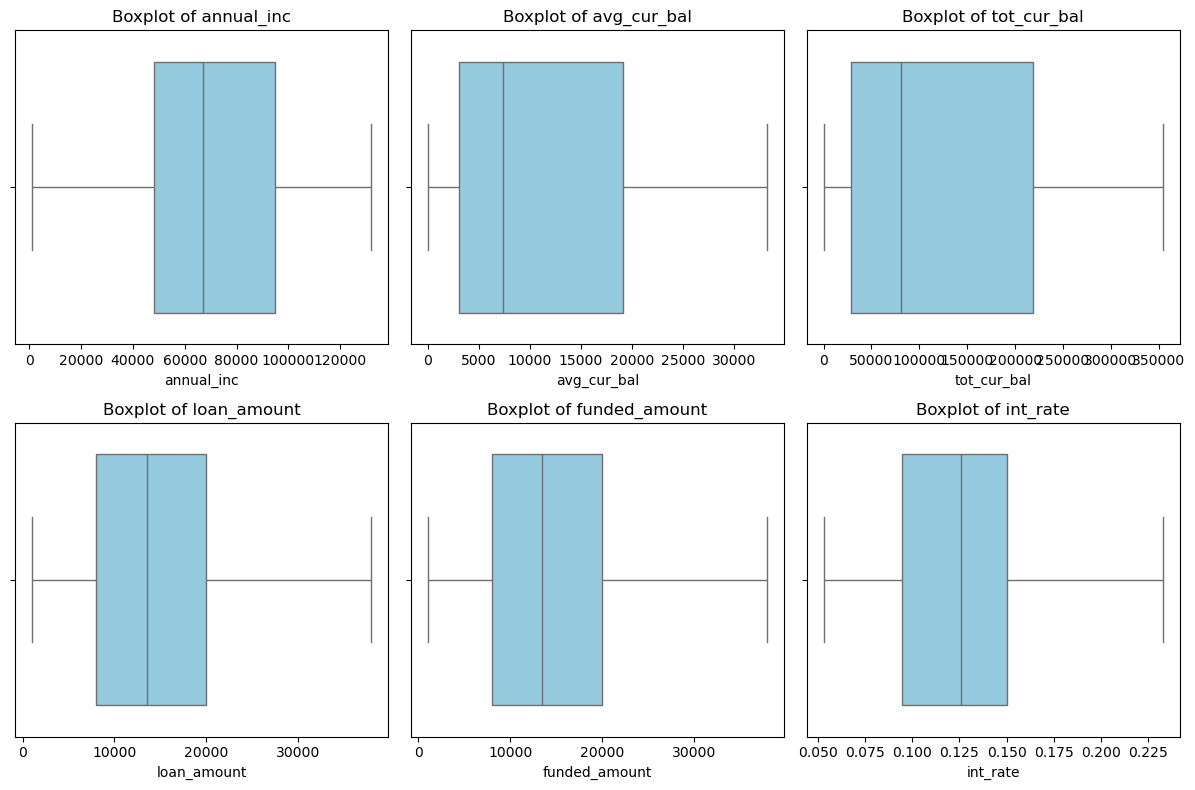

In [82]:
#for 'annual_inc', 'avg_cur_bal' and 'tot_cur_bal' we will replace outliers with the 90th percentile (capping)
# this choice is because extreme values is totally valid in these columns, since many people in the dataset can have large incomes and balances

#for 'loan_amount', 'funded_amount' and 'int_rate' we will replace outliers with the median
# this choice is to reduce skewness without biasing the distribution (if replaced with the mean)
# here, we did not do the same approach as the first 3 columns because these columns have meaningful limits in our dataset
# ex: loan amounts here are not beyond 40,000 and interest rates typically will not increase above a certain limit

columns_to_cap = ['annual_inc', 'avg_cur_bal', 'tot_cur_bal']

for col in columns_to_cap:
    # Calculate the 90th percentile
    upper_limit = df2[col].quantile(0.9)
    
    # Cap the outliers at the upper limit
    df2.loc[:, col] = df2[col].apply(lambda x: upper_limit if x > upper_limit else x)

columns_to_replace = ['loan_amount', 'funded_amount', 'int_rate']

for col in columns_to_replace:
    # Calculate the median for the column
    median_value = df2[col].median()

    # Calculate IQR to identify outliers
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)
    IQR = Q3 - Q1
    cut_off = IQR * 1.5
    lower = Q1 - cut_off
    upper = Q3 + cut_off

    # Replace outliers with the median
    df2.loc[:, col] = df2[col].apply(lambda x: median_value if x < lower or x > upper else x)

#now let's see the box plots after handling the outliers
columns_after = ['annual_inc', 'avg_cur_bal', 'tot_cur_bal', 'loan_amount', 'funded_amount', 'int_rate']

# Set the figure size
plt.figure(figsize=(12, 8))

# Loop through each column and create a boxplot
for i, column in enumerate(columns_after, 1):
    plt.subplot(2, 3, i)  # Create subplots, 2 rows, 3 columns
    sns.boxplot(x=df2[column], color='skyblue')
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)

# Adjust the layout so plots don’t overlap
plt.tight_layout()
plt.show()

In [126]:
#add month column
df2.loc[:, 'issue_date'] = pd.to_datetime(df2['issue_date'])
df2.loc[:, 'month_number'] = df2['issue_date'].dt.month

print(df2[['issue_date', 'month_number']].head())

#add salary can cover colummn
df2.loc[:, 'salary_can_cover'] = df2['annual_inc'] >= df2['loan_amount']

print(df2[['annual_inc', 'loan_amount', 'salary_can_cover']].head())

#add letter grade column
def letter_grade(grade):
    if 1 <= grade <= 5:
        return 'A'
    elif 6 <= grade <= 10:
        return 'B'
    elif 11 <= grade <= 15:
        return 'C'
    elif 16 <= grade <= 20:
        return 'D'
    elif 21 <= grade <= 25:
        return 'E'
    elif 26 <= grade <= 30:
        return 'F'
    elif 31 <= grade <= 35:
        return 'G'
    else:
        return None  # For grades outside the defined ranges

df2.loc[:, 'letter_grade'] = df2['grade'].apply(letter_grade)

print(df2[['grade', 'letter_grade']].head())

        issue_date  month_number
loan_id                         
168686  2014-10-14            10
134771  2018-05-18             5
189329  2017-12-17            12
6602    2013-08-13             8
192847  2018-12-18            12
         annual_inc  loan_amount  salary_can_cover
loan_id                                           
168686      66000.0      16000.0              True
134771      65000.0      13000.0              True
189329     108000.0      20000.0              True
6602        24000.0       2400.0              True
192847      65544.0      20000.0              True
         grade letter_grade
loan_id                    
168686      16            D
134771      19            D
189329       4            A
6602        11            C
192847      10            B


In [192]:
df2 = df2.copy()

# Use the 'term' column as 'n' in the installment formula (loan term in months)
# before we can use 'term' column, we should convert it from object to integer first
df2['term'] = df2['term'].str.extract(r'(\d+)').astype(int)

print(df2['term'].head())

loan_id
168686    60
134771    60
189329    36
6602      36
192847    36
Name: term, dtype: int32


In [200]:
#add installment per month column
df2.loc[:, 'monthly_int_rate'] = df2['int_rate'] / 12

df2.loc[:, 'installment_per_month'] = (df2['loan_amount'] * 
                                 df2['monthly_int_rate'] * 
                                 (1 + df2['monthly_int_rate']) ** df2['term']) / \
                                ((1 + df2['monthly_int_rate']) ** df2['term'] - 1)

df2 = df2.drop(columns=['monthly_int_rate'])

df2['installment_per_month'] = df2['installment_per_month'].astype(float)

# Check the results
print(df2[['loan_amount', 'int_rate', 'term', 'installment_per_month']].head())

         loan_amount  int_rate  term  installment_per_month
loan_id                                                    
168686       16000.0    0.1699    60             397.555186
134771       13000.0    0.1845    60             333.305189
189329       20000.0    0.0735    36             620.747480
6602          2400.0    0.1522    36              83.455585
192847       20000.0    0.1180    36             662.377338


In [232]:
#now encoding
# we will use label encoding for all the categorical columns except for 'home_ownership', 'verification_status' and 'type' columns
# these columns will use one hot encoding instead
# the reason for this is because one hot encoding fixes the problem of hierarchy/order since order in these 3 columns makes no sense
# also, these 3 columns have low number of unique values, so they will not expand the dataset much
from sklearn.preprocessing import LabelEncoder

def label_encode_columns(df, label_encode_cols):
    # Create a copy of the DataFrame to avoid modifying the original
    df_encoded = df.copy()
    
    label_encoder = LabelEncoder()
    
    for col in label_encode_cols:
        df_encoded[col] = label_encoder.fit_transform(df_encoded[col])
    
    return df_encoded


def one_hot_encode_columns(df, one_hot_encode_cols):
    df_encoded = df.copy()
    
    df_encoded = pd.get_dummies(df_encoded, columns=one_hot_encode_cols, drop_first=True)
    
    return df_encoded

# Define the categorical columns for encoding
label_encode_columns_list = [
    'emp_title', 
    'emp_length', 
    'zip_code', 
    'addr_state', 
    'loan_status', 
    'state', 
    'purpose', 
    'letter_grade'
]

one_hot_encode_columns_list = ['home_ownership', 'verification_status', 'type']

df_encoded = label_encode_columns(df2, label_encode_columns_list)
df_encoded = one_hot_encode_columns(df_encoded, one_hot_encode_columns_list)

# Check the result
df_encoded.head()

,customer_id,emp_title,emp_length,annual_inc,annual_inc_joint,zip_code,addr_state,avg_cur_bal,tot_cur_bal,loan_status,...,salary_can_cover,letter_grade,installment_per_month,home_ownership_Mortgage,home_ownership_Own,home_ownership_Rent,verification_status_Source Verified,verification_status_Verified,type_Individual,type_Joint
loan_id,,,,,,,,,,,,,,,,,,,,,
168686,YidnXHhlMzRceGRiXHgxYUxceDhjXlx4YzYiXHhjY1NceD...,8207,4,66000.0,NaN,480,22,14224.0,227591.0,1,...,True,3,397.555186,True,False,False,True,False,True,False
134771,YidFUlx4ZjM1XHhjYlx4YzJceDg4XHg5YTZceDFlXHgwNl...,7223,1,65000.0,NaN,446,21,13361.0,80168.0,1,...,True,3,333.305189,False,False,True,False,True,True,False
189329,YiddXHhkN1BceDBiU1x4ZTlceGRibVx4OTVkMlx4ZjlceG...,884,3,108000.0,NaN,778,4,7366.0,228343.0,1,...,True,0,620.747480,False,False,True,True,False,True,False
6602,YidaaVx4YzFceGFjXHhkY1x4ZTFceDk4XHgwNUNceGJjXH...,6481,5,24000.0,NaN,132,37,4732.0,28393.0,3,...,True,2,83.455585,False,False,True,False,False,True,False
192847,YidceGU4XHhmZFx4MWNbXHhmY1x4YjNceGMyXHg5OFZceD...,2419,1,65544.0,NaN,177,8,19839.0,277757.0,1,...,True,1,662.377338,True,False,False,False,True,True,False


In [306]:
df2.describe()
#based on the output we will normalize the columns whose standard deviation is relatively large, which are:
# 'annual_inc', 'avg_cur_bal', 'tot_cur_bal', 'loan_amount', 'funded_amount' and 'installment_per_month'
#note that we ignored the 'annual_inc_joint' column because we will drop it anyways

from scipy.stats import boxcox

def boxcox_normalization(df, columns):
    # Create a copy of the DataFrame to avoid modifying the original
    df_norm = df.copy()
    
    # Dictionary to store lambda values for each column (useful if we need to reverse Box-Cox)
    lambdas_dict = {}
    
    for col in columns:
        # Ensure the column has only positive values
        positive_values = df_norm[col] > 0
        positive_data = df_norm.loc[positive_values, col]
        
        # Apply Box-Cox transformation and store lambda
        df_norm.loc[positive_values, col], lambda_value = boxcox(positive_data)
        lambdas_dict[col] = lambda_value
    
    return df_norm, lambdas_dict

# Define the columns to normalize
columns_to_normalize = ['annual_inc', 'avg_cur_bal', 'loan_amount', 'funded_amount', 'tot_cur_bal', 'installment_per_month']

# Apply the normalization function
df_norm, lambdas_dict = boxcox_normalization(df_encoded, columns_to_normalize)

# Check the result
df_norm[columns_to_normalize].describe()
#the 'std' values now are a lot better than before

,annual_inc,avg_cur_bal,loan_amount,funded_amount,tot_cur_bal,installment_per_month
count,26800.000000,26800.000000,26800.000000,26800.000000,26800.000000,26800.000000
mean,309.787853,23.371909,110.810658,110.810658,56.042574,19.163901
std,64.615745,5.838702,28.735877,28.735877,16.233218,4.496596
min,45.791289,0.000000,37.556458,37.556458,0.000000,6.384807
25%,264.270442,18.705102,89.963588,89.963588,42.700666,16.260061
50%,306.658424,22.949849,111.629224,111.629224,55.240351,18.931426
75%,358.282894,28.503584,131.182360,131.182360,70.751901,22.235959
max,414.778605,32.194231,170.572963,170.572963,79.711169,31.271372


In [258]:
#now for the lookup table
#first, we will take a copy of the original dataframe and just remove the rows of the 'description' column that we dropped
# in order for all dataframes to be of the same size (shape)
df_test = df.copy()
df_test = df_test.dropna(subset=['description'])

import pandas as pd

def lookup_table(original_df, imputed_df, encoded_df, imputed_columns, encoded_columns):
    # Create an empty list to hold the lookup data
    lookup_data = []

    # Reset the index of all DataFrames to ensure they are aligned
    original_df = original_df.reset_index(drop=False)
    imputed_df = imputed_df.reset_index(drop=False)
    encoded_df = encoded_df.reset_index(drop=False)

    # Imputation tracking
    for col in imputed_columns:
        # Check if the column exists in both DataFrames
        if col not in original_df.columns or col not in imputed_df.columns:
            print(f"Warning: Column '{col}' not found in one of the DataFrames. Skipping this column.")
            continue

        # Calculate the mean of the column in the imputed DataFrame (if numeric)
        if pd.api.types.is_numeric_dtype(imputed_df[col]):
            mean_value = imputed_df[col].mean()
        else:
            mean_value = None  # No mean calculation for non-numeric types

        # Create a mask for where the original value was NaN and the imputed value is not
        mask = original_df[col].isnull() & imputed_df[col].notnull()
        
        if mask.any():
            for imputed_value in imputed_df[col][mask]:
                imputed_str = f"{imputed_value} (mean)" if mean_value is not None and imputed_value == mean_value else imputed_value
                lookup_data.append({'Column': col, 'Original': 'missing', 'Imputed': imputed_str})

        # For cases where original value is different but not NaN
        if col in original_df.columns:  # Only check for differences if the column exists in original_df
            changed_mask = original_df[col] != imputed_df[col]
            if changed_mask.any():
                for original_value, imputed_value in zip(original_df[col][changed_mask], imputed_df[col][changed_mask]):
                    imputed_str = f"{imputed_value} (mean)" if mean_value is not None and imputed_value == mean_value else imputed_value
                    lookup_data.append({'Column': col, 'Original': original_value, 'Imputed': imputed_str})

    # Encoding tracking
    for col in encoded_columns:
        # Check if the column exists in the encoded DataFrame
        if col not in encoded_df.columns:
            print(f"Warning: Column '{col}' not found in encoded_df. Skipping this column.")
            continue

        # Get unique original values; check if it exists in original_df
        if col in original_df.columns:
            original_values = original_df[col].unique()  # Get unique original values
        else:
            print(f"Warning: Column '{col}' not found in original_df. Skipping original values.")
            original_values = []  # No original values available

        encoded_values = encoded_df[col].unique()  # Get unique encoded values

        for original in original_values:
            encoded = encoded_values[0] if len(encoded_values) > 0 else None
            lookup_data.append({'Column': col, 'Original': original, 'Imputed': encoded})

    # Convert the lookup data into a DataFrame
    lookup_df = pd.DataFrame(lookup_data)
    
    return lookup_df

imputed_columns = ['int_rate', 'emp_title', 'emp_length', 'annual_inc', 'avg_cur_bal', 'tot_cur_bal', 'loan_amount', 'funded_amount']  # Imputed columns
encoded_columns = ['emp_title', 'emp_length', 'zip_code', 'addr_state', 'loan_status', 'state', 'purpose', 'letter_grade', 'home_ownership', 
                   'verification_status', 'type']  # Encoded columns

lookup_df = lookup_table(df_test, df2, df_encoded, imputed_columns, encoded_columns)

# Save the lookup DataFrame to a CSV file
lookup_df.to_csv('lookup_table.csv', index=False)

lookup_df

,Column,Original,Imputed
0,int_rate,missing,0.1259
1,int_rate,missing,0.1259
2,int_rate,missing,0.1259
3,int_rate,missing,0.1259
4,int_rate,missing,0.1259
...,...,...,...
35243,purpose,medical,2
35244,purpose,vacation,2
35245,purpose,house,2
35246,purpose,renewable_energy,2


In [308]:
#now that we are done with most of our work, we will drop the 'annual_inc_joint' column 
df_norm = df_norm.drop('annual_inc_joint', axis=1)
df_norm

,customer_id,emp_title,emp_length,annual_inc,zip_code,addr_state,avg_cur_bal,tot_cur_bal,loan_status,loan_amount,...,salary_can_cover,letter_grade,installment_per_month,home_ownership_Mortgage,home_ownership_Own,home_ownership_Rent,verification_status_Source Verified,verification_status_Verified,type_Individual,type_Joint
loan_id,,,,,,,,,,,,,,,,,,,,,
168686,YidnXHhlMzRceGRiXHgxYUxceDhjXlx4YzYiXHhjY1NceD...,8207,4,304.609365,480,22,26.680413,71.491852,1,119.703475,...,True,3,19.360410,True,False,False,True,False,True,False
134771,YidFUlx4ZjM1XHhjYlx4YzJceDg4XHg5YTZceDFlXHgwNl...,7223,1,302.542925,446,21,26.307166,55.156865,1,109.909362,...,True,3,18.071629,False,False,True,False,True,True,False
189329,YiddXHhkN1BceDBiU1x4ZTlceGRibVx4OTVkMlx4ZjlceG...,884,3,379.339146,778,4,22.966788,71.550038,1,131.182360,...,True,0,22.981333,False,False,True,True,False,True,False
6602,YidaaVx4YzFceGFjXHhkY1x4ZTFceDk4XHgwNUNceGJjXH...,6481,5,193.861037,132,37,20.714874,42.401645,3,54.466023,...,True,2,10.221232,False,False,True,False,False,True,False
192847,YidceGU4XHhmZFx4MWNbXHhmY1x4YjNceGMyXHg5OFZceD...,2419,1,303.669249,177,8,28.739683,75.086749,1,131.182360,...,True,1,23.555708,True,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144648,YidceGE3flx4YjVceDAyXT1eXHg5Nlx4OWUgYlx4YzhKRi...,7344,3,269.129346,304,9,19.169238,46.559611,1,116.571171,...,True,1,20.825728,False,False,True,True,False,True,False
61475,YidceDk1XHhhOFx4MDc0eTJceGI5XHg4ZXBceGVjczFceG...,10573,6,209.111912,796,4,16.067721,32.288337,3,89.963588,...,True,0,16.134055,False,False,True,True,False,True,False
191593,YidceGRkXHg4MkliXHgwOF5ceGE5XHgxZVx4OTJceGY1XH...,4927,4,401.218767,462,47,16.996634,51.347470,1,131.182360,...,True,1,23.376558,False,False,True,False,True,True,False


In [310]:
#now for the bonus task
import requests

# Step 1: Set the API URL and headers with the access token
api_url = "https://www.universal-tutorial.com/api/states/United States"
headers = {
    "Authorization": "ZfGigq8p1JneMrI6i7DP39X6CZxuIqUQOj9_71NzGiS9Bd7k2apHUV1Oaay_NqGofDU",  # Replace with your actual access token
    "Accept": "application/json"
}

# Step 2: Make the API request to get U.S. state data
response = requests.get(api_url, headers=headers)

# Step 3: Check the response status and handle errors
if response.status_code == 200:
    try:
        state_data = response.json()  # Parse the JSON response

        # Step 4: Create a dictionary to map abbreviations to state names
        state_dict = {state['state_code']: state['state_name'] for state in state_data}

        # Step 5: Map the abbreviations in df2 to full state names
        df2['state_name'] = df2['state'].map(state_dict)

    except requests.exceptions.JSONDecodeError:
        print("Error: Could not parse the API response as JSON.")
else:
    print(f"Error: Received a {response.status_code} status code from the API.")

#this api does not work, it returns error 404 not found when testing the link

Error: Received a 500 status code from the API.


In [312]:
# Step 1: API URL for REST Countries (which includes the US states and territories)
api_url = "https://restcountries.com/v3.1/all"
response = requests.get(api_url)

# Step 2: Check the response status and handle errors
if response.status_code == 200:
    try:
        country_data = response.json()  # Parse the JSON response

        # Step 3: Filter for only U.S. data (you can further filter by U.S. states or regions if needed)
        us_data = next(item for item in country_data if item['cca3'] == 'USA')  # Filter to get USA data

        # Sample to check what data is available for U.S.
        print(us_data)

    except requests.exceptions.JSONDecodeError:
        print("Error: Could not parse the API response as JSON.")
else:
    print(f"Error: Received a {response.status_code} status code from the API.")

#this api works, but it doesn't include state names as we wish

{'name': {'common': 'United States', 'official': 'United States of America', 'nativeName': {'eng': {'official': 'United States of America', 'common': 'United States'}}}, 'tld': ['.us'], 'cca2': 'US', 'ccn3': '840', 'cca3': 'USA', 'cioc': 'USA', 'independent': True, 'status': 'officially-assigned', 'unMember': True, 'currencies': {'USD': {'name': 'United States dollar', 'symbol': '$'}}, 'idd': {'root': '+1', 'suffixes': ['201', '202', '203', '205', '206', '207', '208', '209', '210', '212', '213', '214', '215', '216', '217', '218', '219', '220', '224', '225', '227', '228', '229', '231', '234', '239', '240', '248', '251', '252', '253', '254', '256', '260', '262', '267', '269', '270', '272', '274', '276', '281', '283', '301', '302', '303', '304', '305', '307', '308', '309', '310', '312', '313', '314', '315', '316', '317', '318', '319', '320', '321', '323', '325', '327', '330', '331', '334', '336', '337', '339', '346', '347', '351', '352', '360', '361', '364', '380', '385', '386', '401', '4

In [314]:
from bs4 import BeautifulSoup

def get_state_mapping():
    url = 'https://www23.statcan.gc.ca/imdb/p3VD.pl?Function=getVD&TVD=53971'

    # Send a GET request to the page
    response = requests.get(url)

    # Check if the request was successful
    if response.status_code == 200:
        # Parse the page content
        soup = BeautifulSoup(response.text, 'html.parser')
        
        # Extract state codes and names
        state_codes = []
        state_names = []
        
        # Find the table
        table = soup.find('table')
        
        if table:
            rows = table.find_all('tr')  # Get all rows in the table
            for row in rows[1:]:  # Skip header row
                cols = row.find_all('td')  # Get columns in the row
                if len(cols) >= 3:  # Ensure there are enough columns
                    state_code = cols[2].text.strip()  # In this website, codes are the third column
                    state_name = cols[0].text.strip()  # and names are the first column
                    if state_code and state_name:  # Check for non-empty values
                        state_codes.append(state_code)
                        state_names.append(state_name)

        # Create a mapping of state codes to state names
        state_mapping = dict(zip(state_codes, state_names))
        return state_mapping  # Return the state mapping

    else:
        print(f"Failed to retrieve the page: {response.status_code}")
        return None  # Return None if the request fails

state_mapping = get_state_mapping()  # Call the function to get the mapping
if state_mapping:  # Check if the mapping was successful
    df2['state_name'] = df2['state'].map(state_mapping)

df2[['state', 'state_name']].head()

#this method works very well using web scraping

,state,state_name
loan_id,,
168686,MN,Minnesota
134771,MI,Michigan
189329,CA,California
6602,PA,Pennsylvania
192847,DE,Delaware


In [316]:
#note that the bonus task is done on df2, so it is not in our final cleaned dataset (df_norm)
# since the milestone description did not mention any of the steps (encoding, norm., etc.) to be applied on this new column 'state_name'
#now let's save our final dataset
df_norm.to_csv('fintech_data_NETW_P2_52_21240_clean.csv', index=False)